## Section 1 – Library Installation & Imports

In [7]:
!pip install pandas numpy scikit-learn imbalanced-learn matplotlib seaborn sqlalchemy pymysql --quiet

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import time

from collections import Counter
from sqlalchemy import create_engine

# Sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_validate, GridSearchCV
)
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve
)

# Imbalanced-learn
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Plotting defaults ─────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':      150,
    'axes.titlesize':  12,
    'axes.labelsize':  10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'font.family':     'DejaVu Sans',
})
COLORS = {
    'major':   '#E53935',
    'minor':   '#1E88E5',
    'cv':      '#1976D2',
    'test':    '#43A047',
    'neutral': '#7B7B7B',
}

print("All libraries imported successfully.")


All libraries imported successfully.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Section 2 – Data Loading from Data Warehouse

In [8]:
# ── Database Connection ───────────────────────────────────────────────────
DB_HOST     = os.getenv('DB_HOST',     'localhost')
DB_PORT     = int(os.getenv('DB_PORT', '3306'))
DB_USER     = os.getenv('DB_USER',     'root')
DB_PASSWORD = os.getenv('DB_PASSWORD', '')
DB_NAME     = os.getenv('DB_NAME',     'datawarehouse_om')

engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)
print(f"Database connection ready: {DB_HOST}:{DB_PORT}/{DB_NAME}")

# ── SQL Query ─────────────────────────────────────────────────────────────
query = """
    SELECT
        f.fact_id,
        f.severity,
        t.month,
        m.scope_of_work,
        s.city,
        s.site_code
    FROM fact_maintenance_activity f
    JOIN dim_time             t  ON f.time_id        = t.time_id
    JOIN dim_maintenance_type m  ON f.maintenance_id = m.maintenance_id
    JOIN dim_site             s  ON f.site_id        = s.site_id
        AND s.is_current = 1
"""

df = pd.read_sql(query, con=engine)
df_raw = df.copy()   # keep original for export

print(f"Data loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(df.head(3))


Database connection ready: localhost:3306/datawarehouse_om
Data loaded: 52,427 rows × 6 columns
   fact_id severity  month scope_of_work                 city   site_code
0     1421    minor      1            q2  kabupaten bondowoso  bdw-07-001
1     5963    minor      2            b4  kabupaten bondowoso  bdw-07-001
2     9883    minor      3           vw2  kabupaten bondowoso  bdw-07-001


## Section 3 – Exploratory Data Analysis (EDA)

In [9]:
# ── 3.1 Basic Info ────────────────────────────────────────────────────────
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape        : {df.shape}")
print(f"Memory usage : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print()
print("Dtypes:")
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())

# ── 3.2 Target Distribution ───────────────────────────────────────────────
print("\nTARGET DISTRIBUTION (severity)")
sev = df['severity'].value_counts()
for label, count in sev.items():
    pct = count / len(df) * 100
    print(f"  {label:<8}: {count:>6,} ({pct:5.1f}%)")
print(f"  Imbalance ratio (minor:major) = {sev.get('minor',0)/max(sev.get('major',1),1):.2f}:1")


DATASET OVERVIEW
Shape        : (52427, 6)
Memory usage : 14252.5 KB

Dtypes:
fact_id           int64
severity         object
month             int64
scope_of_work    object
city             object
site_code        object
dtype: object

Missing values per column:
fact_id          0
severity         0
month            0
scope_of_work    0
city             0
site_code        0
dtype: int64

Duplicate rows: 0

TARGET DISTRIBUTION (severity)
  minor   : 42,796 ( 81.6%)
  major   :  9,631 ( 18.4%)
  Imbalance ratio (minor:major) = 4.44:1


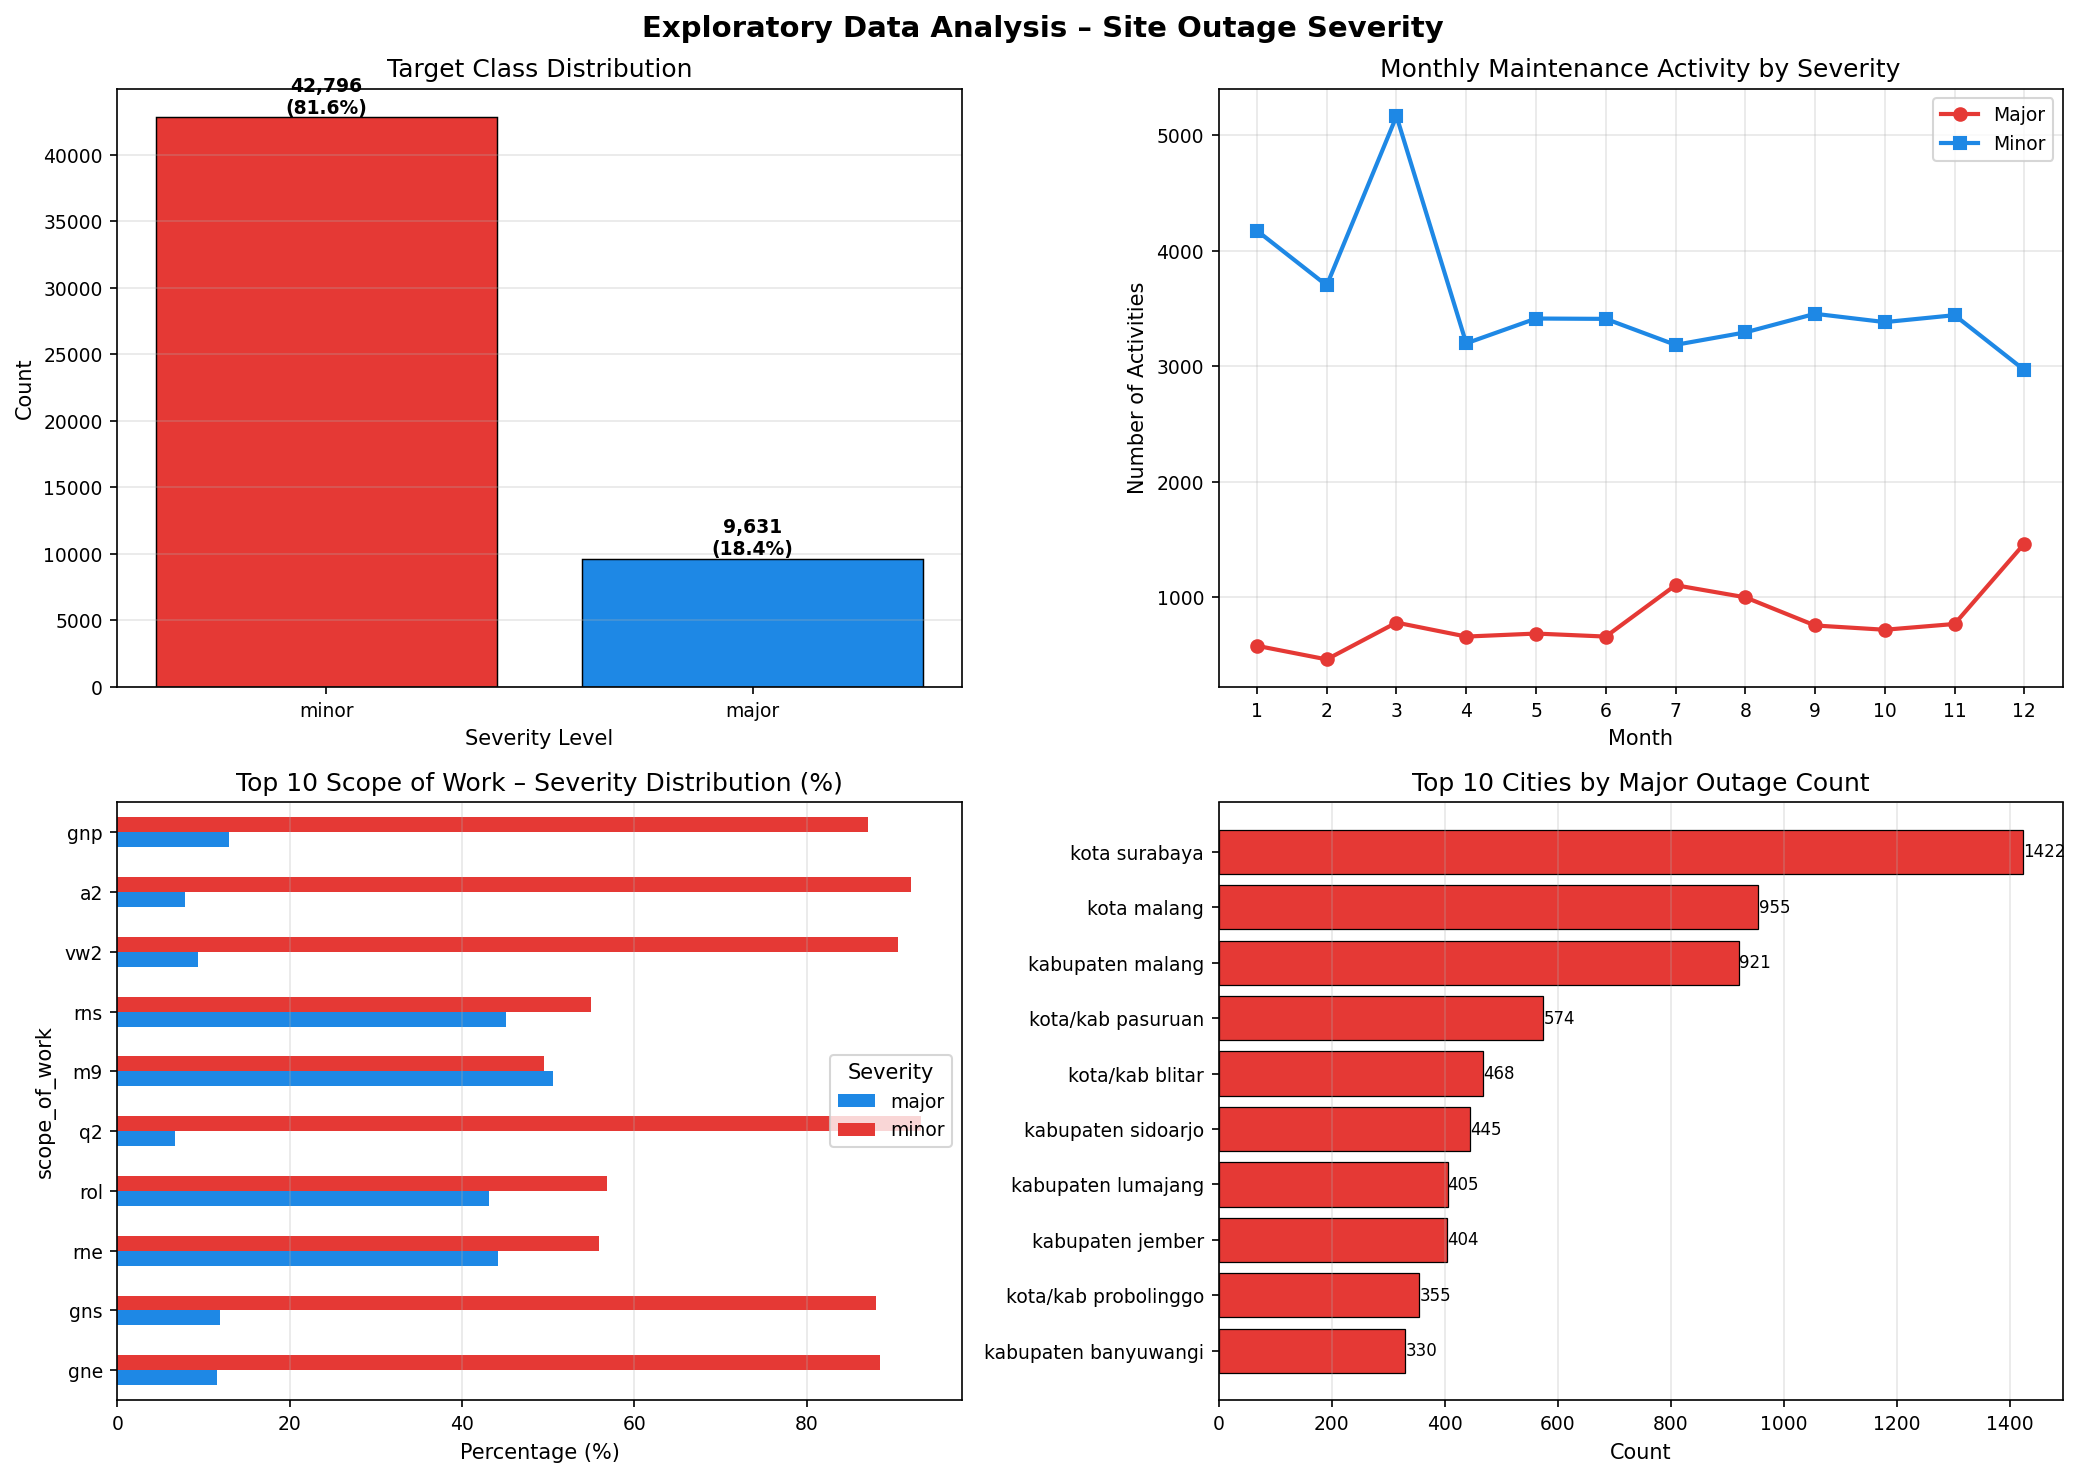

Figure saved: eda_overview.png


In [ ]:
# ── 3.3 EDA Visualisation (4-panel) ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Exploratory Data Analysis – Site Outage Severity', fontsize=14, fontweight='bold')

# Panel 1: Target class distribution
ax = axes[0, 0]
sev_counts = df['severity'].value_counts()
bars = ax.bar(sev_counts.index, sev_counts.values,
              color=[COLORS['major'], COLORS['minor']], edgecolor='black', linewidth=0.7)
for bar, val in zip(bars, sev_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Target Class Distribution')
ax.set_xlabel('Severity Level')
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.3)

# Panel 2: Monthly trend
ax = axes[0, 1]
monthly = df.groupby(['month', 'severity']).size().unstack(fill_value=0)
if 'major' in monthly.columns and 'minor' in monthly.columns:
    ax.plot(monthly.index, monthly['major'], marker='o', color=COLORS['major'], label='Major', linewidth=2)
    ax.plot(monthly.index, monthly['minor'], marker='s', color=COLORS['minor'], label='Minor', linewidth=2)
ax.set_title('Monthly Maintenance Activity by Severity')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Activities')
ax.set_xticks(range(1, 13))
ax.legend()
ax.grid(alpha=0.3)

# Panel 3: Scope of Work distribution
ax = axes[1, 0]
scope_sev = df.groupby(['scope_of_work', 'severity']).size().unstack(fill_value=0)
scope_sev_pct = scope_sev.div(scope_sev.sum(axis=1), axis=0) * 100
if not scope_sev_pct.empty:
    top_scopes = scope_sev.sum(axis=1).nlargest(10).index
    scope_sev_pct.loc[top_scopes].plot(
        kind='barh', ax=ax,
        color=[COLORS['minor'], COLORS['major']] if 'minor' in scope_sev_pct.columns else None
    )
ax.set_title('Top 10 Scope of Work – Severity Distribution (%)')
ax.set_xlabel('Percentage (%)')
ax.legend(title='Severity')
ax.grid(axis='x', alpha=0.3)

# Panel 4: Top cities by major severity
ax = axes[1, 1]
city_major = (df[df['severity'] == 'major']
              .groupby('city').size()
              .nlargest(10)
              .reset_index(name='count'))
bars = ax.barh(city_major['city'], city_major['count'],
               color=COLORS['major'], edgecolor='black', linewidth=0.6)
for bar, val in zip(bars, city_major['count']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=8)
ax.set_title('Top 10 Cities by Major Outage Count')
ax.set_xlabel('Count')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

plt.show()

## Section 4 – Data Preparation & Class Imbalance Handling

In [11]:
# ── 4.1 Type Conversion ───────────────────────────────────────────────────
NUM_COLS = ['month']
for col in NUM_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ── 4.2 Feature & Target Definition ──────────────────────────────────────
FEATURE_COLS = ['month', 'scope_of_work', 'city', 'site_code']
TARGET_COL   = 'severity'
CAT_COLS     = ['scope_of_work', 'city', 'site_code']

label_encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str).str.strip().str.lower())
    label_encoders[col] = le
    print(f"  Encoded '{col}' → {len(le.classes_)} unique classes")

# Encode target
df['severity_encoded'] = df[TARGET_COL].str.strip().str.lower().map({'minor': 0, 'major': 1})
X = df[FEATURE_COLS].copy()
y = df['severity_encoded'].copy()

print(f"\nFeatures (X): {X.shape}")
print(f"Target   (y): {y.shape}  →  0 = minor, 1 = major")
print(f"Class distribution: {Counter(y)}")

# ── 4.3 Train/Test Split (80:20) ──────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain set: {len(X_train):,} samples")
print(f"Test  set: {len(X_test):,} samples")
print(f"Train class distribution (before resampling): {Counter(y_train)}")

# ── 4.4 Random Under Sampling on Train Set ────────────────────────────────
rus = RandomUnderSampler(sampling_strategy=0.6, random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)
print(f"\nAfter RUS: {Counter(y_train_res)}")
print(f"Imbalance ratio after RUS: {Counter(y_train_res)[0] / Counter(y_train_res)[1]:.2f}:1")


  Encoded 'scope_of_work' → 52 unique classes
  Encoded 'city' → 31 unique classes
  Encoded 'site_code' → 8033 unique classes

Features (X): (52427, 4)
Target   (y): (52427,)  →  0 = minor, 1 = major
Class distribution: Counter({0: 42796, 1: 9631})

Train set: 41,941 samples
Test  set: 10,486 samples
Train class distribution (before resampling): Counter({0: 34236, 1: 7705})

After RUS: Counter({0: 12841, 1: 7705})
Imbalance ratio after RUS: 1.67:1


## Section 5 – Comparison with Baseline Classifiers

Classifier                Acc     Prec      Rec       F1      AUC
--------------------------------------------------------------
Decision Tree          0.7222   0.7896   0.7222   0.7459   0.6696
Naive Bayes            0.7753   0.7732   0.7753   0.7742   0.6755
Random Forest          0.7284   0.7934   0.7284   0.7512   0.7842  ◄ PROPOSED


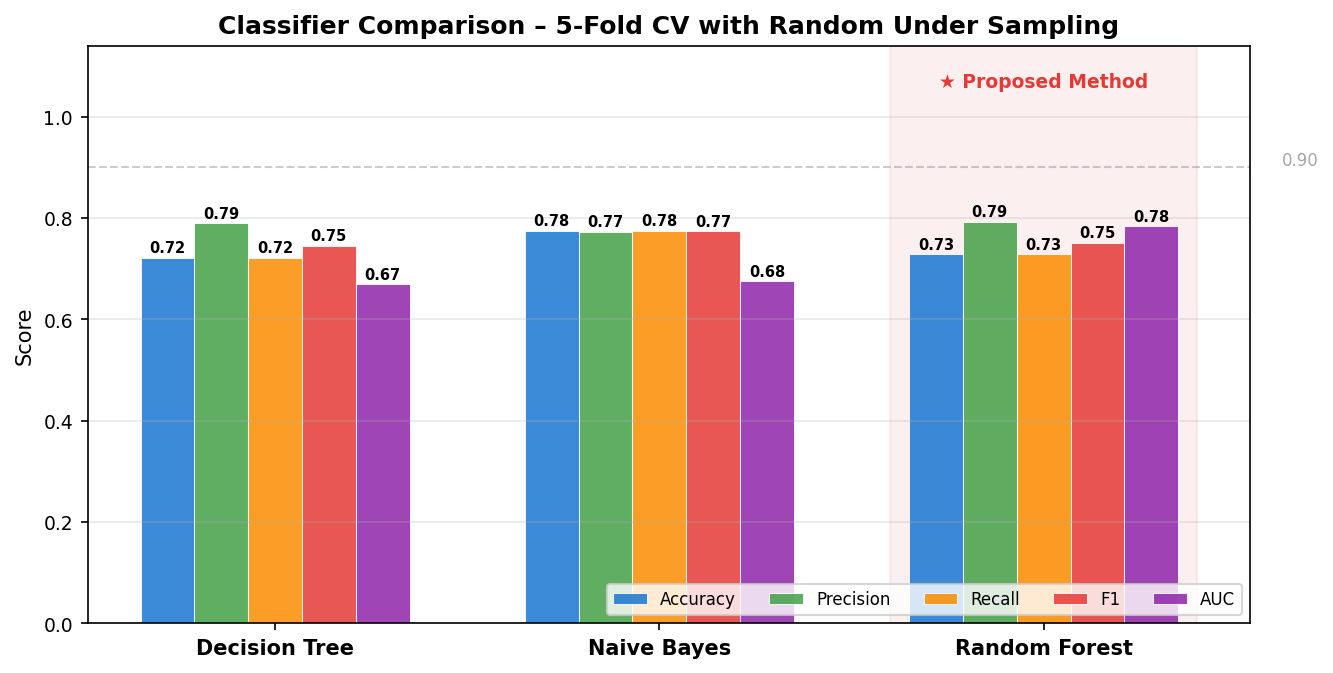

In [23]:
# ── 5.1 Baseline Comparison (3 Classifiers) ─────────────────────────────
# Random Forest is evaluated against two standard baselines:
#   • Decision Tree  — single-tree model; highlights the benefit of ensembling
#   • Naive Bayes    — lightweight probabilistic baseline
# All models use the same RUS pipeline and 5-Fold Stratified CV for fairness.

baselines = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Naive Bayes':   GaussianNB(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_baseline = {}

print(f"{'Classifier':<20} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8} {'AUC':>8}")
print("-" * 62)

for name, clf in baselines.items():
    pipeline = ImbPipeline([
        ('rus', RandomUnderSampler(sampling_strategy=0.6, random_state=42)),
        ('clf', clf)
    ])
    cv_res = cross_validate(
        pipeline, X, y,
        cv=skf5,
        scoring=['accuracy', 'precision_weighted', 'recall_weighted',
                 'f1_weighted', 'roc_auc'],
        n_jobs=-1,
    )
    results_baseline[name] = {
        'Accuracy':  cv_res['test_accuracy'].mean(),
        'Precision': cv_res['test_precision_weighted'].mean(),
        'Recall':    cv_res['test_recall_weighted'].mean(),
        'F1':        cv_res['test_f1_weighted'].mean(),
        'AUC':       cv_res['test_roc_auc'].mean(),
        'F1_std':    cv_res['test_f1_weighted'].std(),
    }
    r = results_baseline[name]
    marker = '  ◄ PROPOSED' if name == 'Random Forest' else ''
    print(f"{name:<20} {r['Accuracy']:>8.4f} {r['Precision']:>8.4f} {r['Recall']:>8.4f} {r['F1']:>8.4f} {r['AUC']:>8.4f}{marker}")

# ── 5.2 Clean Bar Chart — RF highlighted ─────────────────────────────────
df_base = pd.DataFrame(results_baseline).T.reset_index().rename(columns={'index': 'Classifier'})
metrics_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(df_base))
w = 0.14
palette = ['#1976D2', '#43A047', '#FB8C00', '#E53935', '#8E24AA']

for i, (metric, color) in enumerate(zip(metrics_plot, palette)):
    bars = ax.bar(x + i*w, df_base[metric], w, label=metric,
                  color=color, alpha=0.85, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, df_base[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

# Highlight RF column group
rf_idx = list(df_base['Classifier']).index('Random Forest')
ax.axvspan(rf_idx - 0.12, rf_idx + len(metrics_plot)*w - 0.02,
           alpha=0.08, color='#E53935', zorder=0)
ax.annotate('★ Proposed Method', xy=(rf_idx + 0.28, 1.05),
            fontsize=9, fontweight='bold', color='#E53935',
            ha='center', va='bottom')

ax.set_xticks(x + 2*w)
ax.set_xticklabels(df_base['Classifier'], fontsize=10, fontweight='bold')
ax.set_ylim(0, 1.14)
ax.set_ylabel('Score')
ax.set_title('Classifier Comparison – 5-Fold CV with Random Under Sampling', fontweight='bold')
ax.legend(loc='lower right', ncol=5, fontsize=8)
ax.axhline(0.90, color='gray', linestyle='--', alpha=0.4, linewidth=1)
ax.text(len(df_base)-0.1, 0.905, '0.90', color='gray', fontsize=8, alpha=0.7)
ax.grid(axis='y', alpha=0.3)

plt.show()

## Section 6 – Hyperparameter Tuning (GridSearchCV)

In [13]:
# ── 6.1 Parameter Grid ────────────────────────────────────────────────────
param_grid = {
    'rf__n_estimators':      [100, 200, 300],
    'rf__max_depth':         [None, 10, 20, 30],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf':  [1, 2, 4],
    'rf__max_features':      ['sqrt', 'log2'],
    'rf__class_weight':      [None, 'balanced'],
}

# Reduced grid for speed — use full grid for final submission
param_grid_fast = {
    'rf__n_estimators':      [100, 200],
    'rf__max_depth':         [None, 10, 20],
    'rf__min_samples_split': [2, 5],
    'rf__min_samples_leaf':  [1, 2],
    'rf__max_features':      ['sqrt', 'log2'],
    'rf__class_weight':      [None, 'balanced'],
}

# Pipeline: RUS → RF
tune_pipeline = ImbPipeline([
    ('rus', RandomUnderSampler(sampling_strategy=0.6, random_state=42)),
    ('rf',  RandomForestClassifier(random_state=42, n_jobs=-1))
])

skf10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print("Running GridSearchCV with 10-Fold Stratified CV…")
print("(Using fast grid; replace param_grid_fast with param_grid for exhaustive search)")

t0 = time.time()
grid_search = GridSearchCV(
    tune_pipeline,
    param_grid_fast,
    cv=skf10,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0,
    refit=True,
    return_train_score=True,
)
grid_search.fit(X_train, y_train)   # use original imbalanced train set; RUS inside pipeline
elapsed = time.time() - t0

print(f"\nGridSearchCV completed in {elapsed:.1f}s")
print(f"Best F1-weighted (CV): {grid_search.best_score_:.4f}")
print(f"Best parameters      : {grid_search.best_params_}")


Running GridSearchCV with 10-Fold Stratified CV…
(Using fast grid; replace param_grid_fast with param_grid for exhaustive search)

GridSearchCV completed in 989.0s
Best F1-weighted (CV): 0.7886
Best parameters      : {'rf__class_weight': None, 'rf__max_depth': 10, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 5, 'rf__n_estimators': 100}


## Section 7 – Final Model Training & Evaluation

In [ ]:
# ── 7.1 Extract Best Params & Retrain ─────────────────────────────────────
best_params_rf = {
    k.replace('rf__', ''): v
    for k, v in grid_search.best_params_.items()
    if k.startswith('rf__')
}
print("Best RF params (extracted):", best_params_rf)

rf_final = RandomForestClassifier(
    **best_params_rf,
    random_state=42,
    n_jobs=-1,
)
rf_final.fit(X_train_res, y_train_res)
print("\nFinal Random Forest model trained on RUS-resampled training data.")

# ── 7.2 Predictions ──────────────────────────────────────────────────────
y_pred       = rf_final.predict(X_test)
y_pred_proba = rf_final.predict_proba(X_test)   # shape (n, 2)

# ── 7.3 Evaluation Metrics ───────────────────────────────────────────────
acc   = accuracy_score(y_test, y_pred)
prec  = precision_score(y_test, y_pred, average='weighted')
rec   = recall_score(y_test,   y_pred, average='weighted')
f1    = f1_score(y_test,       y_pred, average='weighted')
auc   = roc_auc_score(y_test,  y_pred_proba[:, 1])
ap    = average_precision_score(y_test, y_pred_proba[:, 1])

# Per-class
prec_major = precision_score(y_test, y_pred, pos_label=1)
rec_major  = recall_score(y_test,    y_pred, pos_label=1)
f1_major   = f1_score(y_test,        y_pred, pos_label=1)
prec_minor = precision_score(y_test, y_pred, pos_label=0)
rec_minor  = recall_score(y_test,    y_pred, pos_label=0)
f1_minor   = f1_score(y_test,        y_pred, pos_label=0)

print("\n" + "=" * 55)
print("FINAL MODEL EVALUATION — RANDOM FOREST (TUNED + RUS)")
print("=" * 55)
print(f"  Accuracy           : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision (wtd)    : {prec:.4f}  ({prec*100:.2f}%)")
print(f"  Recall    (wtd)    : {rec:.4f}  ({rec*100:.2f}%)")
print(f"  F1-Score  (wtd)    : {f1:.4f}  ({f1*100:.2f}%)")
print(f"  ROC-AUC            : {auc:.4f}")
print(f"  Avg Precision (AP) : {ap:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['minor', 'major']))

Best RF params (extracted): {'class_weight': None, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

Final Random Forest model trained on RUS-resampled training data.

FINAL MODEL EVALUATION — RANDOM FOREST (TUNED + RUS)
  Accuracy           : 0.7672  (76.72%)
  Precision (wtd)    : 0.8174  (81.74%)
  Recall    (wtd)    : 0.7672  (76.72%)
  F1-Score  (wtd)    : 0.7847  (78.47%)
  ROC-AUC            : 0.8239
  Avg Precision (AP) : 0.4355

              precision    recall  f1-score   support

       minor       0.91      0.80      0.85      8560
       major       0.41      0.64      0.50      1926

    accuracy                           0.77     10486
   macro avg       0.66      0.72      0.68     10486
weighted avg       0.82      0.77      0.78     10486



## Section 8 – 10-Fold Stratified Cross-Validation

10-FOLD STRATIFIED CROSS-VALIDATION RESULTS
Metric                        Mean      Std      Min      Max
----------------------------------------------------------
Accuracy                    0.7719   0.0066   0.7600   0.7818
Precision (wtd)             0.8183   0.0061   0.8068   0.8259
Recall (wtd)                0.7719   0.0066   0.7600   0.7818
F1-Score (wtd)              0.7883   0.0059   0.7779   0.7972
ROC-AUC                     0.8211   0.0099   0.8052   0.8337


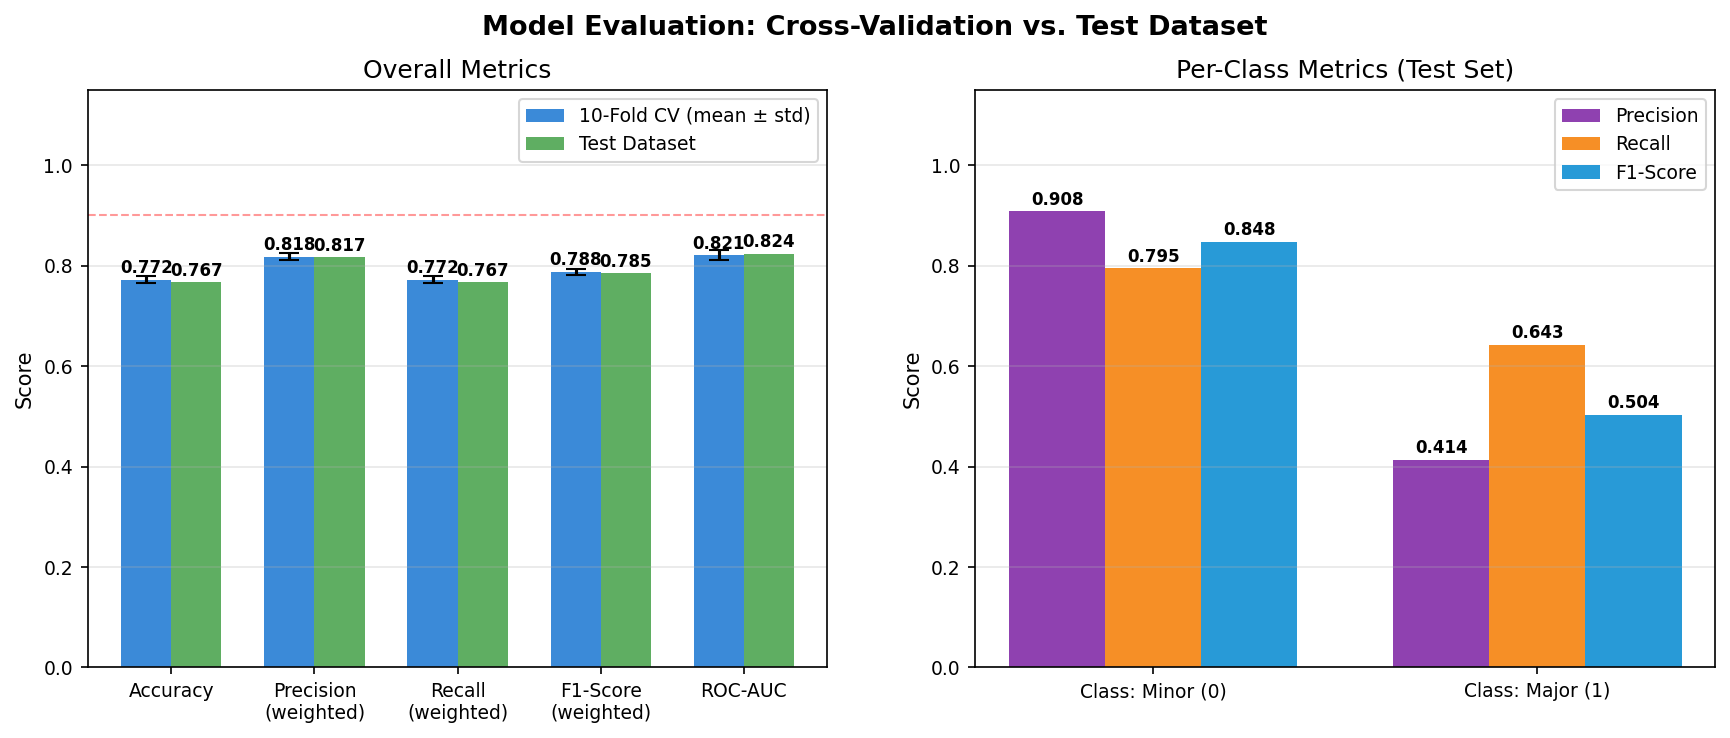

In [22]:
# ── 8.1 CV with Best Params ───────────────────────────────────────────────
cv_pipeline = ImbPipeline([
    ('rus', RandomUnderSampler(sampling_strategy=0.6, random_state=42)),
    ('rf',  RandomForestClassifier(**best_params_rf, random_state=42, n_jobs=-1))
])

skf10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_results = cross_validate(
    cv_pipeline, X, y,
    cv      = skf10,
    scoring = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'roc_auc'],
    n_jobs  = -1,
)

print("10-FOLD STRATIFIED CROSS-VALIDATION RESULTS")
print(f"{'Metric':<25} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-" * 58)
cv_metric_map = [
    ('Accuracy',           'test_accuracy'),
    ('Precision (wtd)',    'test_precision_weighted'),
    ('Recall (wtd)',       'test_recall_weighted'),
    ('F1-Score (wtd)',     'test_f1_weighted'),
    ('ROC-AUC',            'test_roc_auc'),
]
for label, key in cv_metric_map:
    vals = cv_results[key]
    print(f"{label:<25} {vals.mean():>8.4f} {vals.std():>8.4f} {vals.min():>8.4f} {vals.max():>8.4f}")

# ── 8.2 CV vs Test Bar Chart ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Evaluation: Cross-Validation vs. Test Dataset', fontsize=13, fontweight='bold')

metrics_labels = ['Accuracy', 'Precision\n(weighted)', 'Recall\n(weighted)', 'F1-Score\n(weighted)', 'ROC-AUC']
cv_means = [cv_results[k].mean() for _, k in cv_metric_map]
cv_stds  = [cv_results[k].std()  for _, k in cv_metric_map]
test_scores = [acc, prec, rec, f1, auc]

ax1 = axes[0]
x   = np.arange(len(metrics_labels))
w   = 0.35
b1  = ax1.bar(x - w/2, cv_means, w, yerr=cv_stds, capsize=5,
              label='10-Fold CV (mean ± std)', color=COLORS['cv'], alpha=0.85)
b2  = ax1.bar(x + w/2, test_scores, w,
              label='Test Dataset', color=COLORS['test'], alpha=0.85)
for bar, val in zip(b1, cv_means):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
for bar, val in zip(b2, test_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax1.set_ylim(0, 1.15)
ax1.set_xticks(x); ax1.set_xticklabels(metrics_labels)
ax1.set_ylabel('Score'); ax1.legend()
ax1.axhline(0.90, color='red', linestyle='--', alpha=0.4, linewidth=1)
ax1.grid(axis='y', alpha=0.3)
ax1.set_title('Overall Metrics')

ax2 = axes[1]
kelas = ['Minor', 'Major']
x2 = np.arange(len(kelas)); w2 = 0.25
ax2.bar(x2 - w2, [prec_minor, prec_major], w2, label='Precision', color='#7B1FA2', alpha=0.85)
ax2.bar(x2,      [rec_minor,  rec_major],  w2, label='Recall',    color='#F57C00', alpha=0.85)
ax2.bar(x2 + w2, [f1_minor,   f1_major],   w2, label='F1-Score',  color='#0288D1', alpha=0.85)
for vals, offset in [([prec_minor, prec_major], -w2),
                     ([rec_minor,  rec_major],  0),
                     ([f1_minor,   f1_major],   w2)]:
    for i, v in enumerate(vals):
        ax2.text(i + offset, v + 0.005, f'{v:.3f}',
                 ha='center', va='bottom', fontsize=8, fontweight='bold')
ax2.set_ylim(0, 1.15)
ax2.set_xticks(x2); ax2.set_xticklabels(['Class: Minor (0)', 'Class: Major (1)'])
ax2.set_ylabel('Score'); ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.set_title('Per-Class Metrics (Test Set)')

plt.show()

## Section 9 – Confusion Matrix Analysis

CONFUSION MATRIX
  True  Positive (TP) — Major predicted as Major :  1238 (64.3%)
  False Negative (FN) — Major predicted as Minor :   688 (35.7%)
  False Positive (FP) — Minor predicted as Major :  1753 (20.5%)
  True  Negative (TN) — Minor predicted as Minor :  6807 (79.5%)


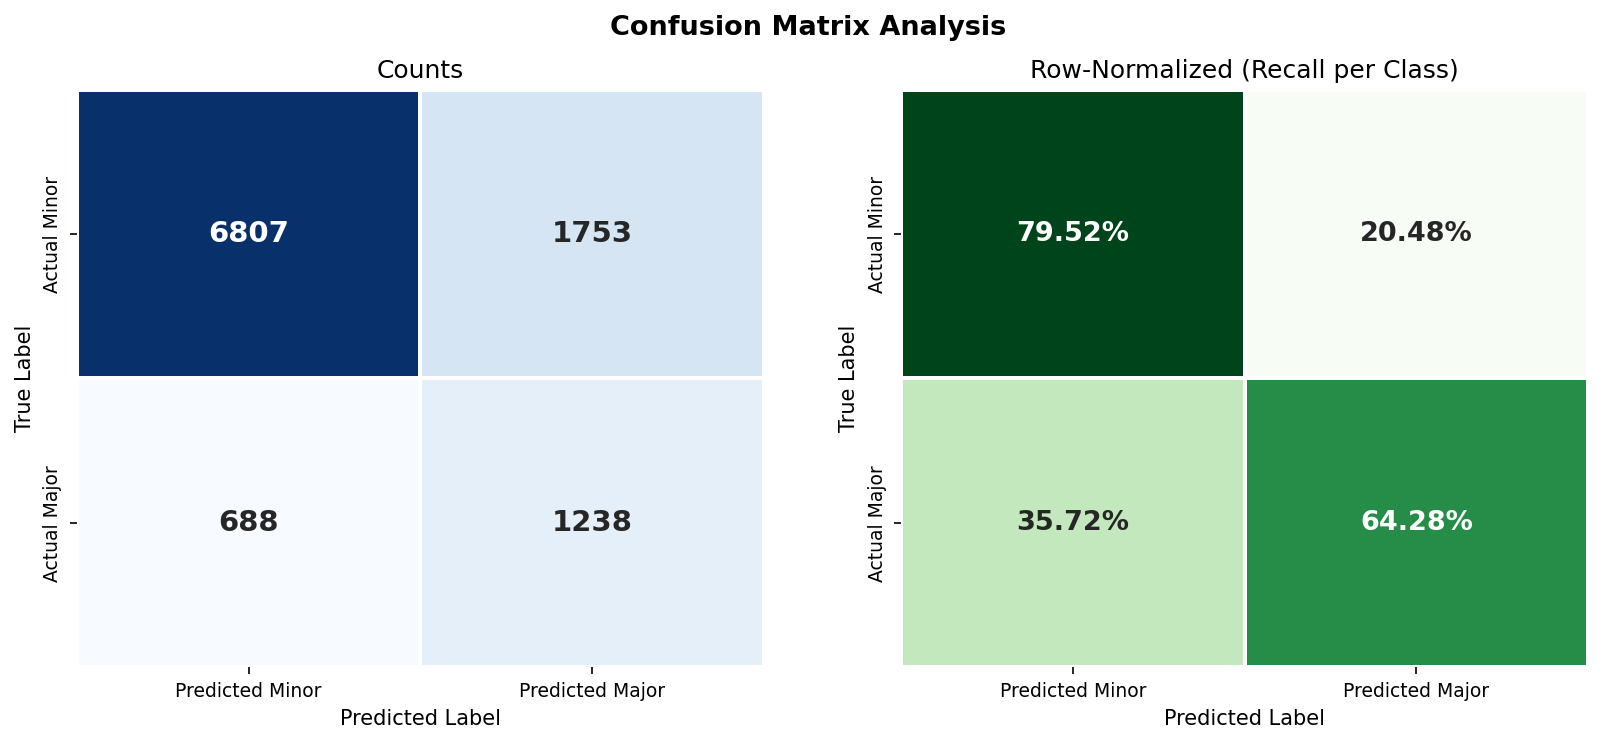

In [24]:
# ── 9.1 Confusion Matrix ──────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

total_major = TP + FN
total_minor = TN + FP

print("CONFUSION MATRIX")
print(f"  True  Positive (TP) — Major predicted as Major : {TP:>5} ({TP/total_major*100:.1f}%)")
print(f"  False Negative (FN) — Major predicted as Minor : {FN:>5} ({FN/total_major*100:.1f}%)")
print(f"  False Positive (FP) — Minor predicted as Major : {FP:>5} ({FP/total_minor*100:.1f}%)")
print(f"  True  Negative (TN) — Minor predicted as Minor : {TN:>5} ({TN/total_minor*100:.1f}%)")

# ── 9.2 Heatmap ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Confusion Matrix Analysis', fontsize=13, fontweight='bold')

# Raw counts
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted Minor', 'Predicted Major'],
    yticklabels=['Actual Minor',    'Actual Major'],
    ax=axes[0], linewidths=1, linecolor='white', cbar=False,
    annot_kws={'size': 14, 'weight': 'bold'}
)
axes[0].set_title('Counts')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Normalised (row-wise)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm, annot=True, fmt='.2%', cmap='Greens',
    xticklabels=['Predicted Minor', 'Predicted Major'],
    yticklabels=['Actual Minor',    'Actual Major'],
    ax=axes[1], linewidths=1, linecolor='white', cbar=False,
    annot_kws={'size': 13, 'weight': 'bold'}
)
axes[1].set_title('Row-Normalized (Recall per Class)')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.show()

## Section 10 – ROC-AUC & Precision-Recall Curves

Optimal classification threshold (Youden's J): 0.236
ROC-AUC  : 0.8239
Avg Prec : 0.4355


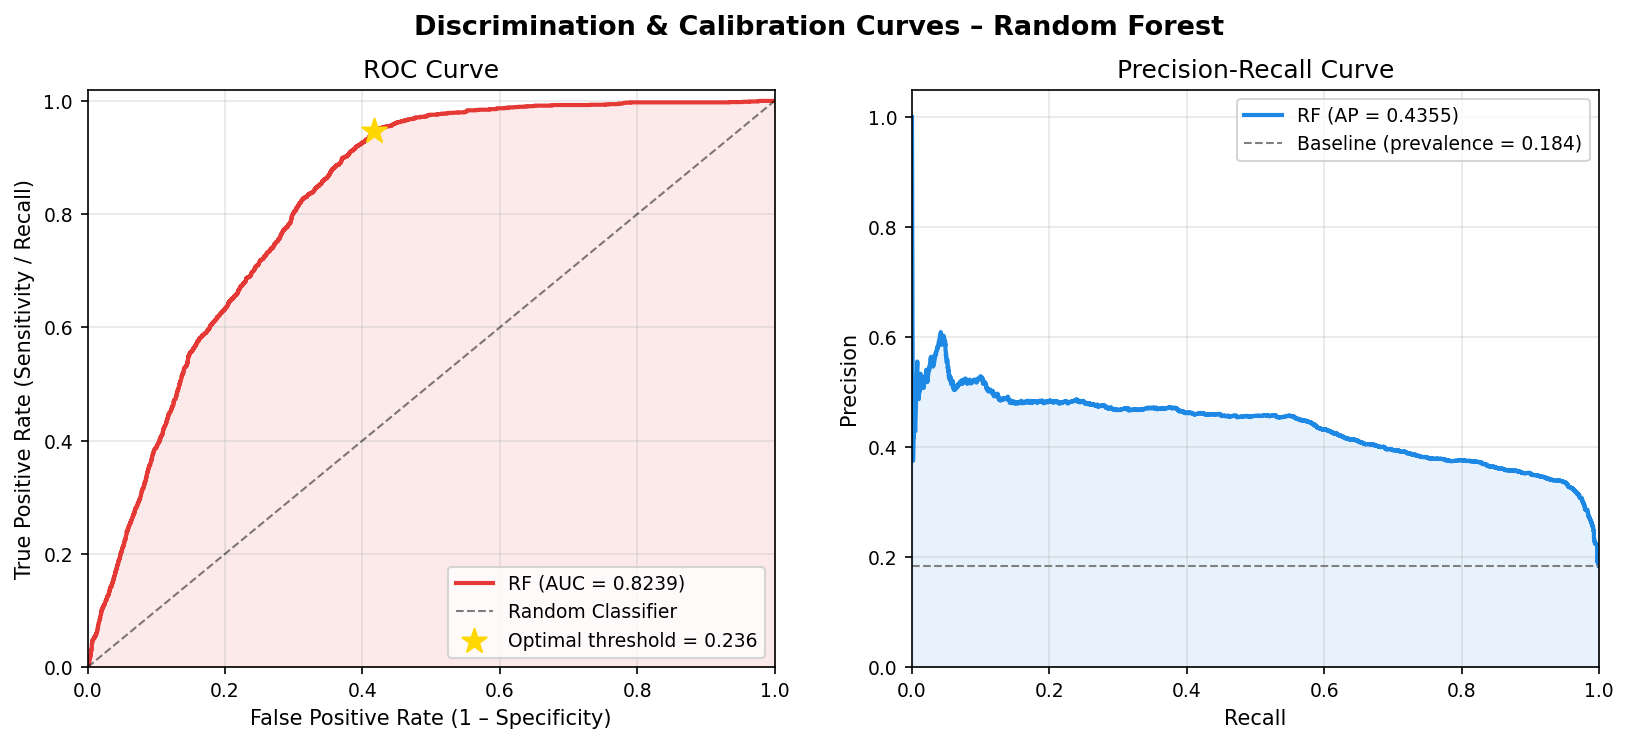

In [25]:
# ── 10.1 ROC Curve ───────────────────────────────────────────────────────
fpr, tpr, roc_thresholds = roc_curve(y_test, y_pred_proba[:, 1])
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_pred_proba[:, 1])

# Optimal threshold (Youden's J)
j_scores    = tpr - fpr
best_thresh = roc_thresholds[np.argmax(j_scores)]
print(f"Optimal classification threshold (Youden's J): {best_thresh:.3f}")
print(f"ROC-AUC  : {auc:.4f}")
print(f"Avg Prec : {ap:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Discrimination & Calibration Curves – Random Forest', fontsize=13, fontweight='bold')

# ROC
ax = axes[0]
ax.plot(fpr, tpr, color=COLORS['major'], lw=2, label=f'RF (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random Classifier')
ax.scatter(fpr[np.argmax(j_scores)], tpr[np.argmax(j_scores)],
           marker='*', s=150, color='gold', zorder=5,
           label=f'Optimal threshold = {best_thresh:.3f}')
ax.fill_between(fpr, tpr, alpha=0.1, color=COLORS['major'])
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate (1 – Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity / Recall)')
ax.set_title('ROC Curve')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

# Precision-Recall
ax = axes[1]
ax.plot(rec_curve, prec_curve, color=COLORS['minor'], lw=2, label=f'RF (AP = {ap:.4f})')
baseline_ap = y_test.mean()
ax.axhline(baseline_ap, color='gray', linestyle='--', lw=1, label=f'Baseline (prevalence = {baseline_ap:.3f})')
ax.fill_between(rec_curve, prec_curve, alpha=0.1, color=COLORS['minor'])
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend()
ax.grid(alpha=0.3)

plt.show()

## Section 11 – Feature Importance & Permutation Importance

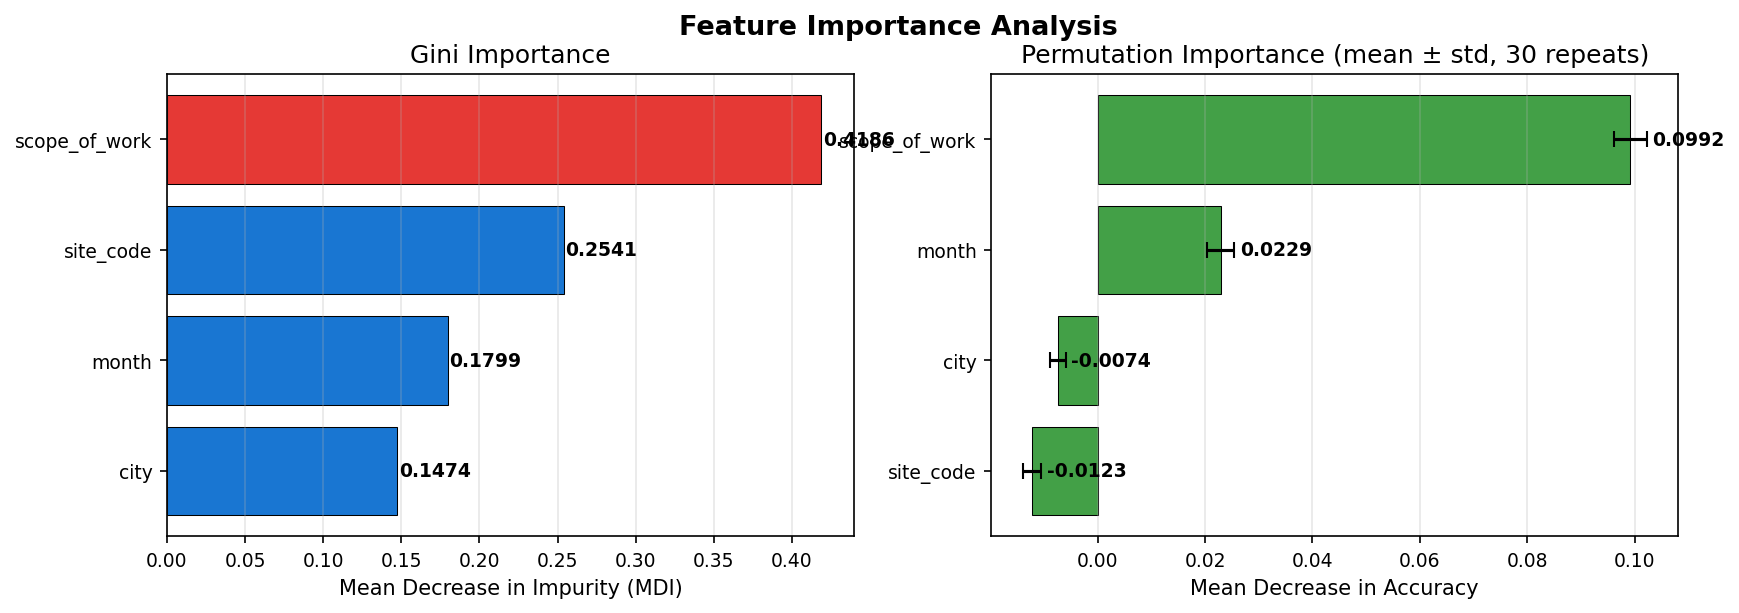


FEATURE IMPORTANCE RANKING
  scope_of_work      MDI=0.4186  █████████████████████████
  site_code          MDI=0.2541  ███████████████
  month              MDI=0.1799  ██████████
  city               MDI=0.1474  ████████


In [26]:
# ── 11.1 Gini-based Feature Importance ───────────────────────────────────
fi_df = pd.DataFrame({
    'Feature':    FEATURE_COLS,
    'Importance': rf_final.feature_importances_
}).sort_values('Importance', ascending=True)

# ── 11.2 Permutation Importance (more reliable) ───────────────────────────
perm_result = permutation_importance(
    rf_final, X_test, y_test,
    n_repeats=30, random_state=42, n_jobs=-1
)
perm_df = pd.DataFrame({
    'Feature':     FEATURE_COLS,
    'Perm_Mean':   perm_result.importances_mean,
    'Perm_Std':    perm_result.importances_std,
}).sort_values('Perm_Mean', ascending=True)

# ── 11.3 Visualisation ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Feature Importance Analysis', fontsize=13, fontweight='bold')

# Gini
ax = axes[0]
colors_fi = ['#1976D2' if fi_df['Feature'].iloc[i] != fi_df['Feature'].iloc[-1]
             else '#E53935' for i in range(len(fi_df))]
bars = ax.barh(fi_df['Feature'], fi_df['Importance'], color=colors_fi, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, fi_df['Importance']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity (MDI)')
ax.set_title('Gini Importance')
ax.grid(axis='x', alpha=0.3)

# Permutation
ax = axes[1]
ax.barh(perm_df['Feature'], perm_df['Perm_Mean'],
        xerr=perm_df['Perm_Std'], color='#43A047', edgecolor='black',
        linewidth=0.5, capsize=4)
for i, (mean, feat) in enumerate(zip(perm_df['Perm_Mean'], perm_df['Feature'])):
    ax.text(mean + perm_df['Perm_Std'].iloc[i] + 0.001, i,
            f'{mean:.4f}', va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Mean Decrease in Accuracy')
ax.set_title('Permutation Importance (mean ± std, 30 repeats)')
ax.grid(axis='x', alpha=0.3)

plt.show()

print("\nFEATURE IMPORTANCE RANKING")
fi_sorted = fi_df.sort_values('Importance', ascending=False)
for i, row in fi_sorted.iterrows():
    bar = '█' * int(row['Importance'] * 60)
    print(f"  {row['Feature']:<18} MDI={row['Importance']:.4f}  {bar}")


## Section 12 – Final Results Summary Table

In [27]:
# ── 12.1 Conference-ready Summary ────────────────────────────────────────
print("=" * 65)
print("  FINAL RESULTS SUMMARY — FOR CONFERENCE PAPER")
print("=" * 65)
print(f"  Dataset        : Maintenance activities Jan–Dec 2025")
print(f"  Features used  : {FEATURE_COLS}")
print(f"  Target class   : severity (major=1, minor=0)")
print(f"  Imbalance handling: Random Under Sampling (ratio 0.6)")
print(f"  Hyperparameter tuning: GridSearchCV, 10-Fold Stratified CV")
print()
print(f"  ── Cross-Validation (10-Fold) ──────────────────────────")
for label, key in cv_metric_map:
    vals = cv_results[key]
    print(f"  {label:<25}: {vals.mean():.4f} ± {vals.std():.4f}")
print()
print(f"  ── Test Set Performance ─────────────────────────────────")
print(f"  Accuracy       : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision (wtd): {prec:.4f}  ({prec*100:.2f}%)")
print(f"  Recall    (wtd): {rec:.4f}  ({rec*100:.2f}%)")
print(f"  F1-Score  (wtd): {f1:.4f}  ({f1*100:.2f}%)")
print(f"  ROC-AUC        : {auc:.4f}")
print(f"  Avg Precision  : {ap:.4f}")
print()
print(f"  ── Per-Class (Test Set) ─────────────────────────────────")
print(f"  {'Class':<10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print(f"  {'-'*43}")
print(f"  {'Minor':<10} {prec_minor:>10.4f} {rec_minor:>10.4f} {f1_minor:>10.4f}")
print(f"  {'Major':<10} {prec_major:>10.4f} {rec_major:>10.4f} {f1_major:>10.4f}")
print()
print(f"  ── Best Hyperparameters ─────────────────────────────────")
for k, v in best_params_rf.items():
    print(f"  {k:<25}: {v}")
print("=" * 65)


  FINAL RESULTS SUMMARY — FOR CONFERENCE PAPER
  Dataset        : Maintenance activities Jan–Dec 2025
  Features used  : ['month', 'scope_of_work', 'city', 'site_code']
  Target class   : severity (major=1, minor=0)
  Imbalance handling: Random Under Sampling (ratio 0.6)
  Hyperparameter tuning: GridSearchCV, 10-Fold Stratified CV

  ── Cross-Validation (10-Fold) ──────────────────────────
  Accuracy                 : 0.7719 ± 0.0066
  Precision (wtd)          : 0.8183 ± 0.0061
  Recall (wtd)             : 0.7719 ± 0.0066
  F1-Score (wtd)           : 0.7883 ± 0.0059
  ROC-AUC                  : 0.8211 ± 0.0099

  ── Test Set Performance ─────────────────────────────────
  Accuracy       : 0.7672  (76.72%)
  Precision (wtd): 0.8174  (81.74%)
  Recall    (wtd): 0.7672  (76.72%)
  F1-Score  (wtd): 0.7847  (78.47%)
  ROC-AUC        : 0.8239
  Avg Precision  : 0.4355

  ── Per-Class (Test Set) ─────────────────────────────────
  Class       Precision     Recall   F1-Score
  ----------------

## Section 13 – Export Prediction Results for Dashboard

In [20]:
# ── 13.1 Decode Predictions ──────────────────────────────────────────────
df_predict = X_test.copy()
df_predict['actual_severity']    = y_test.values
df_predict['predicted_severity'] = y_pred
df_predict['confidence_minor']   = y_pred_proba[:, 0]
df_predict['confidence_major']   = y_pred_proba[:, 1]
df_predict['correct_prediction'] = (y_test.values == y_pred).astype(int)

for col in CAT_COLS:
    le = label_encoders[col]
    df_predict[col] = le.inverse_transform(df_predict[col].astype(int))

df_predict['actual_severity']    = df_predict['actual_severity'].map({0: 'Minor', 1: 'Major'})
df_predict['predicted_severity'] = df_predict['predicted_severity'].map({0: 'Minor', 1: 'Major'})

df_predict['confidence_score'] = df_predict.apply(
    lambda r: r['confidence_major'] if r['predicted_severity'] == 'Major' else r['confidence_minor'],
    axis=1
)

fi_sorted_export = fi_df.sort_values('Importance', ascending=False)['Feature'].tolist()
df_predict['top_factor_1'] = fi_sorted_export[0]
df_predict['top_factor_2'] = fi_sorted_export[1] if len(fi_sorted_export) > 1 else ''

df_predict = df_predict.rename(columns={
    'site_code': 'nama_site',
    'city':      'kota_kabupaten',
})

# ── 13.2 Export CSV ───────────────────────────────────────────────────────
cols_export = [
    'nama_site', 'kota_kabupaten', 'month', 'scope_of_work',
    'actual_severity', 'predicted_severity', 'confidence_score',
    'confidence_minor', 'confidence_major',
    'correct_prediction', 'top_factor_1', 'top_factor_2'
]
df_export = df_predict[[c for c in cols_export if c in df_predict.columns]].copy()
df_export['month']            = df_export['month'].astype(int)
df_export['confidence_score'] = df_export['confidence_score'].round(4)
df_export['confidence_minor'] = df_export['confidence_minor'].round(4)
df_export['confidence_major'] = df_export['confidence_major'].round(4)

df_export.to_csv('hasil_prediksi_severity.csv', index=False)

print(f"✓ Export successful: hasil_prediksi_severity.csv")
print(f"  Total records : {len(df_export):,}")
print(f"  Columns       : {list(df_export.columns)}")
print()
print(df_export.head(5).to_string())


✓ Export successful: hasil_prediksi_severity.csv
  Total records : 10,486
  Columns       : ['nama_site', 'kota_kabupaten', 'month', 'scope_of_work', 'actual_severity', 'predicted_severity', 'confidence_score', 'confidence_minor', 'confidence_major', 'correct_prediction', 'top_factor_1', 'top_factor_2']

        nama_site      kota_kabupaten  month scope_of_work actual_severity predicted_severity  confidence_score  confidence_minor  confidence_major  correct_prediction   top_factor_1 top_factor_2
31680  njk-07-088   kabupaten nganjuk      1            a5           Minor              Minor            0.9267            0.9267            0.0733                   1  scope_of_work    site_code
10540  jmr-07-088    kabupaten jember      5           gne           Minor              Minor            0.9971            0.9971            0.0029                   1  scope_of_work    site_code
45062  sda-07-279  kabupaten sidoarjo     10           rns           Major              Major            0